In [4]:
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

In [6]:
load_dotenv("db/.env")

user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
db = os.getenv("DB_NAME")

In [7]:
print(user)
print(port)
print(db)

postgres
5432
car_sales


In [8]:
engine = create_engine(
    f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{db}"
)

In [9]:
df = pd.read_sql("SELECT * FROM sales", engine)

df.head()

,datum,marke,modell,preis_euro,verkaufszahl,kraftstoff,getriebe,hubraum_l,bundesland,kundenzufriedenheit,jahr,monat,wochentag
0,2024-01-01,Mercedes-Benz,C-Klasse,66835,2,Elektro,Automatik,0.0,Berlin,4.7,2024,1,Monday
1,2024-01-01,Mercedes-Benz,E-Klasse,93803,2,Benzin,Manuell,1.2,Nrw,3.2,2024,1,Monday
2,2024-01-07,Volkswagen,Passat,45929,6,Hybrid,Manuell,2.0,Baden-Württemberg,3.2,2024,1,Sunday
3,2024-01-07,Mercedes-Benz,C-Klasse,76943,3,Diesel,Automatik,4.0,Berlin,3.4,2024,1,Sunday
4,2024-01-08,Bmw,5Er,107912,1,Elektro,Automatik,0.0,Berlin,3.2,2024,1,Monday


In [10]:
print(df.columns.tolist())

['datum', 'marke', 'modell', 'preis_euro', 'verkaufszahl', 'kraftstoff', 'getriebe', 'hubraum_l', 'bundesland', 'kundenzufriedenheit', 'jahr', 'monat', 'wochentag']


In [11]:
df["kundenzufriedenheit"].describe()

count    1200.000000
mean        4.021583
std         0.586184
min         3.000000
25%         3.500000
50%         4.000000
75%         4.500000
max         5.000000
Name: kundenzufriedenheit, dtype: float64

In [12]:
df["kundenzufriedenheit"].value_counts().sort_index()

kundenzufriedenheit
3.0    29
3.1    56
3.2    67
3.3    61
3.4    50
3.5    60
3.6    63
3.7    54
3.8    54
3.9    56
4.0    58
4.1    56
4.2    53
4.3    56
4.4    67
4.5    67
4.6    68
4.7    72
4.8    60
4.9    61
5.0    32
Name: count, dtype: int64

In [14]:
df["zufrieden"] = (df["kundenzufriedenheit"] >= 4.0).astype(int)

In [15]:
df["zufrieden"].value_counts()

zufrieden
1    650
0    550
Name: count, dtype: int64

In [16]:
X = df.drop(columns=["kundenzufriedenheit", "zufrieden"])

y = df["zufrieden"]

print(X.shape)
print(y.shape)

(1200, 12)
(1200,)


In [17]:
X_encoded = pd.get_dummies(X, drop_first=True)

print(X_encoded.shape)

(1200, 610)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(960, 610)
(240, 610)
(960,)
(240,)


In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Modell trainiert!")

Modell trainiert!


In [20]:
from sklearn.metrics import accuracy_score

y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5083333333333333


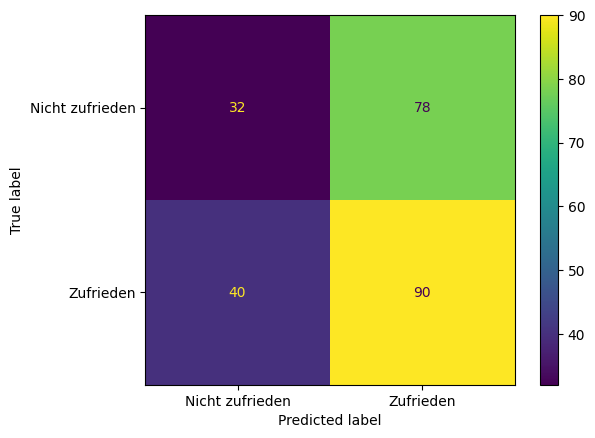

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Nicht zufrieden", "Zufrieden"]
)

disp.plot()
plt.show()

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.44      0.29      0.35       110
           1       0.54      0.69      0.60       130

    accuracy                           0.51       240
   macro avg       0.49      0.49      0.48       240
weighted avg       0.49      0.51      0.49       240



In [23]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,preis_euro,0.090196
4,monat,0.063818
1,verkaufszahl,0.059897
2,hubraum_l,0.044440
598,getriebe_Manuell,0.022023
3,jahr,0.020395
597,kraftstoff_Hybrid,0.015723
596,kraftstoff_Elektro,0.015371
600,bundesland_Berlin,0.014705
606,wochentag_Sunday,0.014394


## Ergebnisse

Für die Klassifikation der Kundenzufriedenheit wurde ein Random-Forest-Klassifikationsmodell verwendet.

Die Zielvariable wurde in zwei Klassen eingeteilt:

- 0 = Nicht zufrieden
- 1 = Zufrieden

Das Modell erreichte eine Accuracy von 50,8 %.

Die wichtigsten Merkmale für die Vorhersage waren:

1. Preis (preis_euro)
2. Monat
3. Verkaufszahl
4. Hubraum
5. Getriebe

Die Ergebnisse zeigen, dass die vorhandenen Merkmale die Kundenzufriedenheit nur begrenzt erklären können. Für eine bessere Vorhersage wären zusätzliche kundenbezogene Merkmale erforderlich.

In [ ]:
#DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.5166666666666667


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_610 = LogisticRegression(max_iter=1000)

lr_610.fit(X_train, y_train)

y_pred_lr_610 = lr_610.predict(X_test)

accuracy_lr_610 = accuracy_score(y_test, y_pred_lr_610)

print("Logistic Regression (610 Features) Accuracy:", accuracy_lr_610)

Logistic Regression (610 Features) Accuracy: 0.4875


C:\Users\hadis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Ergebnisse und Merkmalsanalyse

Für dieses Experiment wurden alle verfügbaren Merkmale des Datensatzes verwendet. Nach dem One-Hot-Encoding entstanden insgesamt 610 numerische Merkmale.

Getestete Modelle:

| Modell | Accuracy |
|----------|----------|
| Random Forest | 50,8 % |
| Logistic Regression | 48,75 % |
| Decision Tree | 51,66 % |

Die beste Genauigkeit wurde mit dem Random-Forest-Modell erzielt.

Die Ergebnisse zeigen, dass die Verwendung einer sehr großen Anzahl von Merkmalen nicht automatisch zu einer besseren Vorhersage führt. Insbesondere die Logistic Regression konnte mit 610 Merkmalen keine gute Leistung erreichen und zeigte zudem Konvergenzprobleme.

Daraus lässt sich schließen, dass viele der erzeugten Merkmale nur einen begrenzten Beitrag zur Vorhersage der Kundenzufriedenheit leisten.